<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec11_regularization_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 정규화 (Regularization) 실습

이 실습에서는 과적합(Overfitting)을 방지하기 위한 정규화 기법을 학습합니다:
1. MLE (Maximum Likelihood Estimation) - 정규화 없음
2. Ridge Regression (L2 정규화)
3. Lasso Regression (L1 정규화)

**정규화 손실 함수:**
- Ridge (L2): $L = \sum(y - \hat{y})^2 + \alpha \sum w_i^2$
- Lasso (L1): $L = \sum(y - \hat{y})^2 + \alpha \sum |w_i|$

**총점: 100점**

**학번:** 2023042028\
**이름:** 권택주

---
## Part 1: 데이터셋 준비 (10점)

노이즈가 포함된 2차 다항식 데이터를 생성합니다.

**Ground Truth:** $y = 0.5x^2 + x + 2$

---

### 문제 1-1. 데이터셋 생성 및 시각화 [10점]

노이즈가 추가된 데이터와 Ground Truth를 시각화합니다.

**예상 결과:** 파란 선(GT)을 중심으로 노이즈가 있는 데이터 포인트

데이터 개수: 150
x 범위: -3.0 ~ 3.0


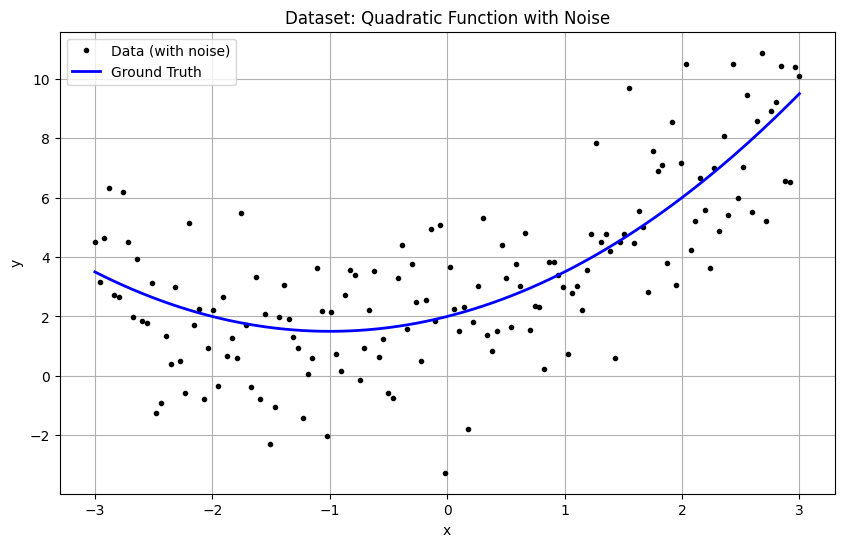

In [1]:
#@title { vertical-output: true}
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

np.random.seed(42)

# Generate synthetic data with noise
m = 150
x = np.linspace(-3, 3, m).reshape(m, 1)
y_gt = 0.5 * x**2 + x + 2  # Ground Truth
y = 0.5 * x**2 + x + 2 + np.random.randn(m, 1) * 2.0  # Noisy data

print(f"데이터 개수: {m}")
print(f"x 범위: {x.min():.1f} ~ {x.max():.1f}")

# Plot data
plt.figure(figsize=(10, 6))
plt.plot(x, y, "k.", label="Data (with noise)")
plt.plot(x, y_gt, "b-", linewidth=2, label="Ground Truth")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset: Quadratic Function with Noise")
plt.grid(True)
plt.show()

---
## Part 2: MLE (정규화 없음) (25점)

정규화 없이 10차 다항식으로 회귀를 수행합니다.

**Pipeline 구성:**
1. PolynomialFeatures: 다항식 특성 생성
2. StandardScaler: 특성 표준화
3. LinearRegression: 선형 회귀

---

### 문제 2-1. MLE 모델 구현 [25점]

sklearn의 make_pipeline을 사용하여 10차 다항식 회귀 모델을 구현합니다.

**문제:**
1. make_pipeline으로 MLE 모델 생성
2. 모델 학습 및 예측

**힌트:**
```python
mle = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    StandardScaler(),
    LinearRegression()
)
mle.fit(x, y)
y_mle = mle.predict(x)
```

**예상 결과:** 과적합된 예측선 (노이즈까지 학습)

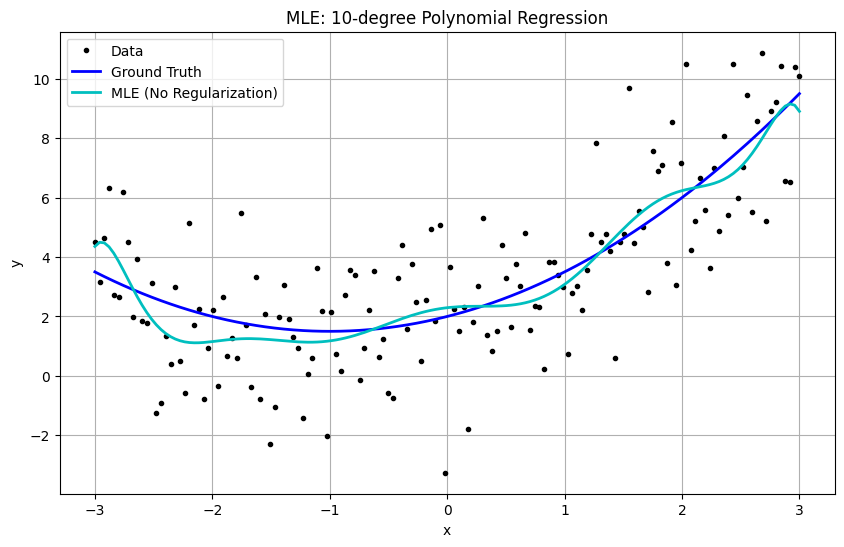

R² score (MLE): 0.6165


In [2]:
#@title { vertical-output: true}
# IMPLEMENT HERE: MLE 파이프라인 생성
# PolynomialFeatures(degree=10), StandardScaler(), LinearRegression()
mle = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    StandardScaler(),
    LinearRegression()
)

# IMPLEMENT HERE: 모델 학습 및 예측
mle.fit(x, y)
y_mle = mle.predict(x)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, "k.", label="Data")
plt.plot(x, y_gt, "b-", linewidth=2, label="Ground Truth")
plt.plot(x, y_mle, "c-", linewidth=2, label="MLE (No Regularization)")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("MLE: 10-degree Polynomial Regression")
plt.grid(True)
plt.show()

print(f"R² score (MLE): {r2_score(y, y_mle):.4f}")

---
## Part 3: Ridge Regression (L2 정규화) (25점)

L2 정규화를 적용한 Ridge Regression을 수행합니다.

**L2 정규화:** 가중치의 제곱합을 최소화하여 가중치 값을 작게 유지

$$L_{Ridge} = \sum(y - \hat{y})^2 + \alpha \sum w_i^2$$

---

### 문제 3-1. Ridge 모델 구현 [25점]

Ridge Regression 모델을 구현합니다.

**문제:**
1. make_pipeline으로 Ridge 모델 생성 (alpha=0.1)
2. 모델 학습 및 예측

**힌트:**
```python
ridge_reg = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    StandardScaler(),
    Ridge(alpha=0.1)
)
ridge_reg.fit(x, y)
y_ridge = ridge_reg.predict(x)
```

**예상 결과:** MLE보다 부드러운 예측선, 계수들이 작은 값

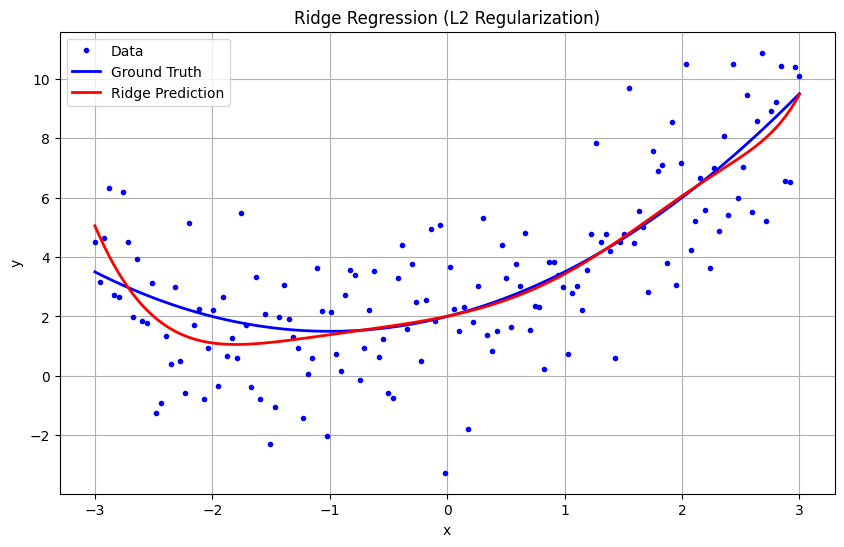

Ridge coefficients:
[ 1.453555    1.09818688  2.22311425 -0.03203995 -1.73759731 -0.36664884
 -1.2911315   0.59222371  1.0452888   0.13015504]

R² score (Ridge): 0.6094


In [3]:
#@title { vertical-output: true}
# IMPLEMENT HERE: Ridge 파이프라인 생성
# PolynomialFeatures(degree=10), StandardScaler(), Ridge(alpha=0.1)
ridge_reg = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    StandardScaler(),
    Ridge(alpha=0.1)
)

# IMPLEMENT HERE: 모델 학습 및 예측
ridge_reg.fit(x, y)
y_ridge = ridge_reg.predict(x)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, "b.", label="Data")
plt.plot(x, y_gt, "b-", linewidth=2, label="Ground Truth")
plt.plot(x, y_ridge, "r-", linewidth=2, label="Ridge Prediction")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ridge Regression (L2 Regularization)")
plt.grid(True)
plt.show()

# Print coefficients
ridge_coef = ridge_reg.named_steps['ridge'].coef_
print("Ridge coefficients:")
print(ridge_coef)
print(f"\nR² score (Ridge): {r2_score(y, y_ridge):.4f}")

---
## Part 4: Lasso Regression (L1 정규화) (25점)

L1 정규화를 적용한 Lasso Regression을 수행합니다.

**L1 정규화:** 가중치의 절댓값 합을 최소화하여 일부 가중치를 0으로 만듦 (Feature Selection)

$$L_{Lasso} = \sum(y - \hat{y})^2 + \alpha \sum |w_i|$$

---

### 문제 4-1. Lasso 모델 구현 [25점]

Lasso Regression 모델을 구현합니다.

**문제:**
1. make_pipeline으로 Lasso 모델 생성 (alpha=0.1)
2. 모델 학습 및 예측

**힌트:**
```python
lasso_reg = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    StandardScaler(),
    Lasso(alpha=0.1, max_iter=10000)
)
lasso_reg.fit(x, y)
y_lasso = lasso_reg.predict(x)
```

**예상 결과:** 일부 계수가 정확히 0인 희소(Sparse) 모델

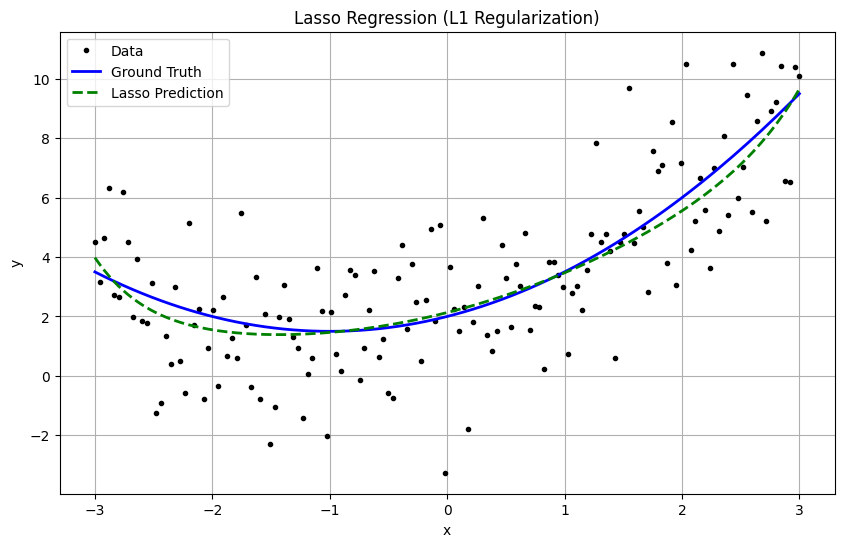

Lasso coefficients:
[ 1.74989786  0.90345278  0.          0.04574585 -0.          0.
 -0.          0.34790559 -0.04188836  0.        ]

0이 아닌 계수 개수: 5
R² score (Lasso): 0.5975


In [4]:
#@title { vertical-output: true}
# IMPLEMENT HERE: Lasso 파이프라인 생성
# PolynomialFeatures(degree=10), StandardScaler(), Lasso(alpha=0.1, max_iter=10000)
lasso_reg = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    StandardScaler(),
    Lasso(alpha=0.1, max_iter=10000)
)

# IMPLEMENT HERE: 모델 학습 및 예측
lasso_reg.fit(x, y)
y_lasso = lasso_reg.predict(x)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, "k.", label="Data")
plt.plot(x, y_gt, "b-", linewidth=2, label="Ground Truth")
plt.plot(x, y_lasso, "g--", linewidth=2, label="Lasso Prediction")
plt.legend()
plt.title("Lasso Regression (L1 Regularization)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

# Print coefficients
lasso_coef = lasso_reg.named_steps['lasso'].coef_
print("Lasso coefficients:")
print(lasso_coef)
print(f"\n0이 아닌 계수 개수: {np.sum(lasso_coef != 0)}")
print(f"R² score (Lasso): {r2_score(y, y_lasso):.4f}")

---
## Part 5: 모델 비교 (15점)

세 가지 모델의 예측 결과를 비교합니다.

---

### 문제 5-1. 모델 비교 시각화 [15점]

MLE, Ridge, Lasso의 예측 결과를 한 그래프에서 비교합니다.

**예상 결과:**
- MLE: 가장 복잡한 곡선 (과적합)
- Ridge: 부드러운 곡선
- Lasso: GT에 가까운 곡선

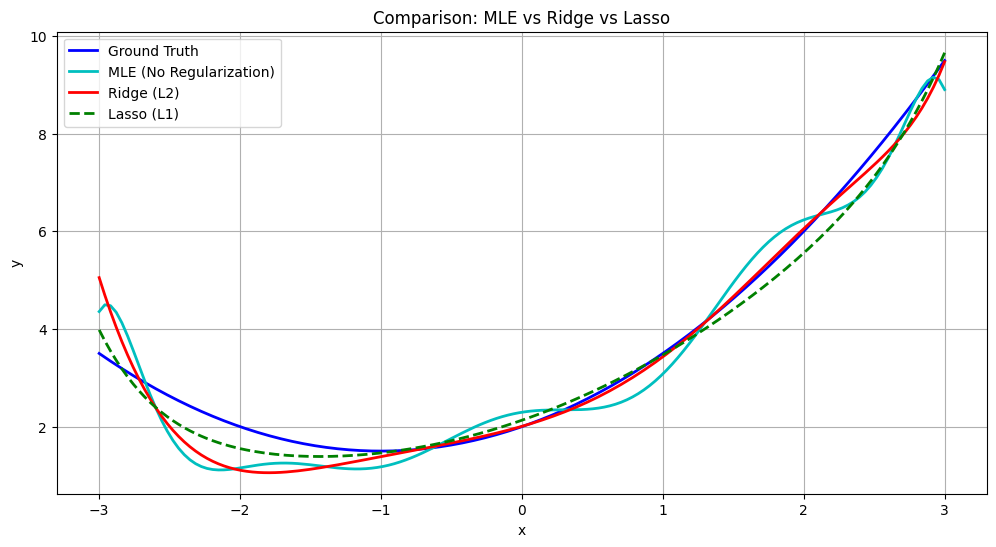

R² Score Comparison (vs Ground Truth)
MLE:   0.9498
Ridge: 0.9653
Lasso: 0.9828


In [5]:
#@title { vertical-output: true}
plt.figure(figsize=(12, 6))
plt.plot(x, y_gt, "b-", linewidth=2, label="Ground Truth")
plt.plot(x, y_mle, "c-", linewidth=2, label="MLE (No Regularization)")
plt.plot(x, y_ridge, "r-", linewidth=2, label="Ridge (L2)")
plt.plot(x, y_lasso, "g--", linewidth=2, label="Lasso (L1)")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison: MLE vs Ridge vs Lasso")
plt.grid(True)
plt.show()

# R² scores comparison
print("=" * 40)
print("R² Score Comparison (vs Ground Truth)")
print("=" * 40)
print(f"MLE:   {r2_score(y_gt, y_mle):.4f}")
print(f"Ridge: {r2_score(y_gt, y_ridge):.4f}")
print(f"Lasso: {r2_score(y_gt, y_lasso):.4f}")

---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `regularization_학번_이름.ipynb`, `regularization_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---